In [82]:
import pandas as pd



In [85]:
import pandas as pd
import os

# Define the data folder path (from your project structure)
data_folder = r'C:\Users\jmofl\PycharmProjects\TimeSeriesProject_Feb_2026\data'
timeseries = pd.read_csv(os.path.join(data_folder, 'cleaned_timeseries.csv'))

## ARIMA Model for Sales Forecasting

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

# 1. Setup Data & Index
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

df.index.freq = 'D'
target = 'unit_sales'

# 2. SPLIT BY DATE: 01.01.2014
# Train: Everything before 2014-01-01
# Test: Everything from 2014-01-01 onwards
train = df.loc[df.index < '2014-01-01']
test = df.loc[df.index >= '2014-01-01']



In [75]:
# 3. Fit ARIMA(3,0,3)
model = ARIMA(train[target], order=(3, 0, 3))
model_fit = model.fit(method_kwargs={'maxiter': 500})




In [76]:
# 4. Forecast for the length of the test set
forecast = model_fit.forecast(steps=len(test))

# 5. Create the Forecast Table with Dates
forecast_table = forecast.to_frame(name='Predicted Sales').reset_index()
forecast_table.columns = ['Date', 'Predicted Sales']



Split Date: 2014-01-01
Mean Absolute Error (MAE): 114.28

--- Forecasted Sales Table (Starting Jan 1, 2014) ---
      Date  Predicted Sales
2014-01-01       326.808361
2014-01-02       390.982589
2014-01-03       485.345977
2014-01-04       592.487473
2014-01-05       604.763702
2014-01-06       526.375347
2014-01-07       409.677550
2014-01-08       346.003691
2014-01-09       381.662833
2014-01-10       490.619063
2014-01-11       590.321146
2014-01-12       605.827696
2014-01-13       525.345224
2014-01-14       409.593021
2014-01-15       345.795850
2014-01-16       382.055156
2014-01-17       491.032165
2014-01-18       590.585597
2014-01-19       605.673119
2014-01-20       524.923691
2014-01-21       409.204483
2014-01-22       345.742080
2014-01-23       382.372226
2014-01-24       491.483303
2014-01-25       590.829630
2014-01-26       605.526662
2014-01-27       524.496864
2014-01-28       408.819159
2014-01-29       345.688635
2014-01-30       382.690979
2014-01-31       491

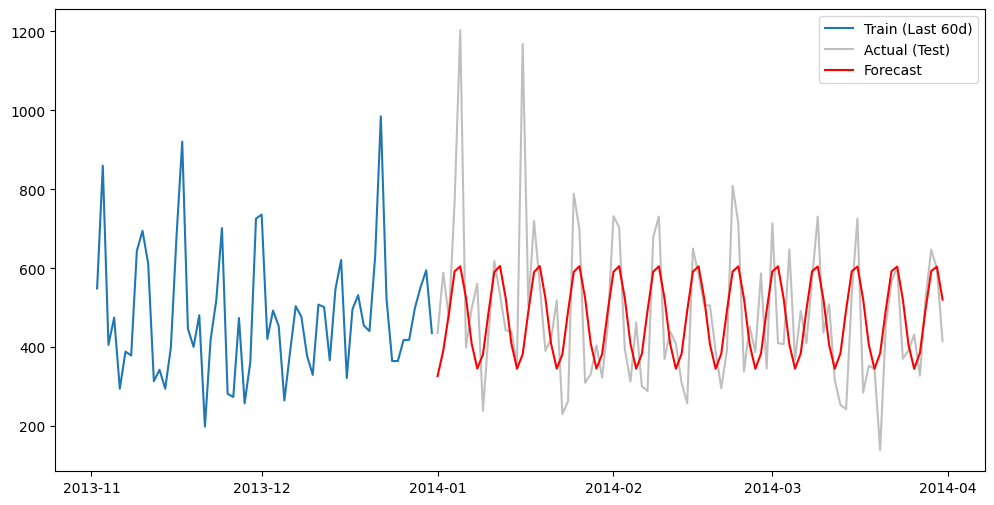

In [77]:
# 6. Print Results
print(f"Split Date: 2014-01-01")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(test[target], forecast):.2f}")
print("\n--- Forecasted Sales Table (Starting Jan 1, 2014) ---")
print(forecast_table.to_string(index=False))

# 7. Plot
plt.figure(figsize=(12, 6))
plt.plot(train.index[-60:], train[target][-60:], label='Train (Last 60d)')
plt.plot(test.index, test[target], label='Actual (Test)', color='gray', alpha=0.5)
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.legend()
plt.show()

In [78]:

#  Save it to a CSV file if you need it in Excel
# forecast_table.to_csv('my_forecast.csv', index=False)


## SARIMA Model for Sales Forecasting

SARIMA MAE: 95.78

--- SARIMA Forecast Table ---
      Date  Predicted Sales
2014-01-01       449.163790
2014-01-02       379.880114
2014-01-03       378.549598
2014-01-04       605.398825
2014-01-05       697.221214
2014-01-06       459.486572
2014-01-07       393.381190
2014-01-08       443.250728
2014-01-09       340.930019
2014-01-10       399.338787
2014-01-11       634.377501
2014-01-12       699.564852
2014-01-13       426.729449
2014-01-14       383.722923
2014-01-15       466.468114
2014-01-16       358.668134
2014-01-17       384.595442
2014-01-18       612.223306
2014-01-19       704.660266
2014-01-20       449.288286
2014-01-21       387.776626
2014-01-22       447.050328
2014-01-23       347.338825
2014-01-24       398.252332
2014-01-25       628.052518
2014-01-26       698.116933
2014-01-27       432.032857
2014-01-28       387.158712
2014-01-29       462.847552
2014-01-30       354.047873
2014-01-31       386.174941
2014-02-01       617.126621
2014-02-02       705.099287

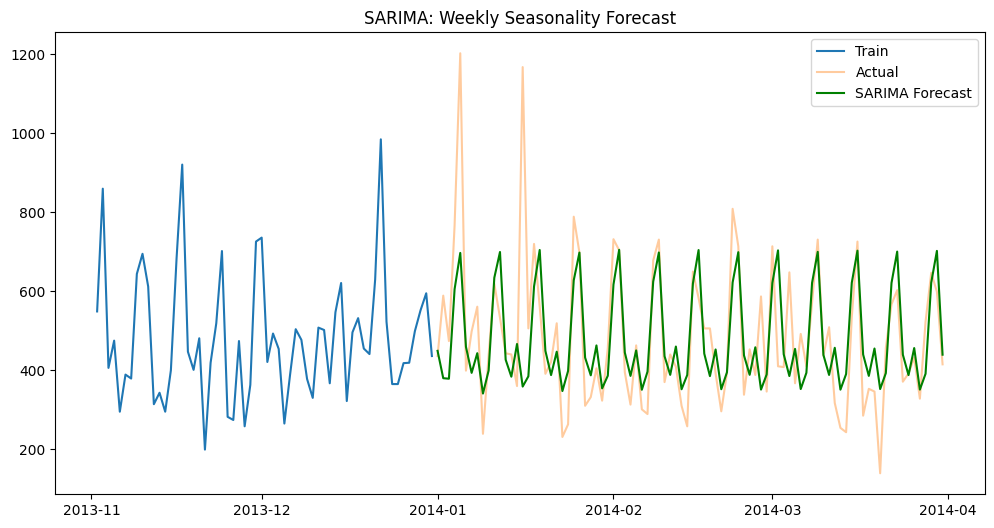

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

# 1. Setup Data & Index
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()

df.index.freq = 'D'
target = 'unit_sales'

# 2. Split by Date: 01.01.2014
train = df.loc[df.index < '2014-01-01']
test = df.loc[df.index >= '2014-01-01']

# 3. Fit SARIMA Model
# order=(p,d,q), seasonal_order=(P,D,Q,s)
# s=7 captures weekly seasonality for daily data
model = SARIMAX(train[target],
                order=(3, 0, 3),
                seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False,
                enforce_invertibility=False)

# Increase maxiter to help with convergence
model_fit = model.fit(maxiter=500, disp=False)

# 4. Forecast and Table
forecast = model_fit.get_forecast(steps=len(test)).predicted_mean
forecast_table = forecast.to_frame(name='Predicted Sales').reset_index()
forecast_table.columns = ['Date', 'Predicted Sales']

# 5. Evaluate and Print
mae = mean_absolute_error(test[target], forecast)
print(f"SARIMA MAE: {mae:.2f}")
print("\n--- SARIMA Forecast Table ---")
print(forecast_table.to_string(index=False))

# 6. Plot
plt.figure(figsize=(12, 6))
plt.plot(train.index[-60:], train[target][-60:], label='Train')
plt.plot(test.index, test[target], label='Actual', alpha=0.4)
plt.plot(test.index, forecast, label='SARIMA Forecast', color='green')
plt.title('SARIMA: Weekly Seasonality Forecast')
plt.legend()
plt.show()
